Model Hyparameters Config

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

# pai
seed = 42
# model = 'llava-v1.5'
# model = 'minigpt4'
model = "instructblip"
# model = "qwen-vl"
sample = False
temperature = -1
top_p = None
num_beams = 1
max_new_tokens = 512

#hyparams
use_jsd = True
alpha = 0.6
beta = 0.6
threshold_top_p = 0.9
threshold_top_k = 20
early_exit_layers=[i for i in range(20, 29, 1)]

In [2]:
import argparse
import json
import random
import numpy as np
import torch
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
from constants import INSTRUCTION_TEMPLATE, SYSTEM_MESSAGE
from eval_data_loader import COCODataSet
from llava.utils import disable_torch_init
from model_loader import ModelLoader
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

def setup_seeds(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    cudnn.benchmark = False
    cudnn.deterministic = True

/home/zhr/.conda/envs/deco/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


load model

In [3]:
setup_seeds(seed)
disable_torch_init()

model_loader = ModelLoader(model)

Loading InstructBlip
Initialization Model


/home/zhr/.conda/envs/deco/lib/python3.9/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You are using the legacy behaviour of the <class 'transformers.models.llama.tokenization_llama.LlamaTokenizer'>. This means that tokens that come after special tokens will not be properly handled. We recommend you to read the related pull request available at https://github.com/huggingface/transformers/pull/24565
Loading checkpoint shards: 100%|██████████| 2/2 [00:07<00:00,  3.77s/it]


Done!


In [4]:
# image_id = 226988
# image_id = 46011
image_id = 344439
image_path = "/data1/zhr/datasets/coco2014/val2014/" + "COCO_val2014_"+str(image_id).zfill(12) + ".jpg"
image = Image.open(image_path).convert("RGB")
# if model == "llava-1.5":
#     image_tensor = model_loader.image_processor.preprocess(image, return_tensors='pt')
# elif model == "qwen-vl":
#     image_tensor = [image_file]
# else:
#     image_tensor = model_loader.image_processor(image).unsqueeze(0)

template = INSTRUCTION_TEMPLATE[model]
query = "Please help me describe the image in detail."

questions, kwargs = model_loader.prepare_inputs_for_model(template, query, image_path)
# # print("input_ids", kwargs["input_ids"].shape)
# print("inputs_embeds", kwargs["inputs_embeds"].shape)
# print("attention_mask", kwargs["attention_mask"].shape)
# print("uncond_inputs_embeds", kwargs["uncond_inputs_embeds"].shape)
# # print("uncond_input_ids", kwargs["uncond_input_ids"].shape)
# print("uncond_attention_mask", kwargs["uncond_attention_mask"].shape)

In [5]:
print(questions)

['<ImageHere>Please help me describe the image in detail.']


In [6]:
with torch.inference_mode():
    outputs = model_loader.llm_model.generate(
        do_sample=sample,
        temperature=temperature,
        top_p=top_p,
        num_beams=num_beams,
        max_new_tokens=max_new_tokens,
        use_cache=True,
        # pad_token_id=model_loader.tokenizer.eod_id,
        # eos_token_id=model_loader.tokenizer.eod_id,
        # use_jsd=use_jsd,
        # alpha = alpha,
        # threshold_top_p=threshold_top_p, 
        # threshold_top_k=threshold_top_k,
        # early_exit_layers=early_exit_layers,
        # return_dict=True,
        # return_dict_in_generate=True,
        # output_hidden_states=True,
        # output_scores=True,
        **kwargs,
    )


/home/zhr/DeCo_JSD/transformers/generation/utils.py:1286: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed soon, in a future version. Please use a generation configuration file (see https://huggingface.co/docs/transformers/main_classes/text_generation )
  warnings.warn(


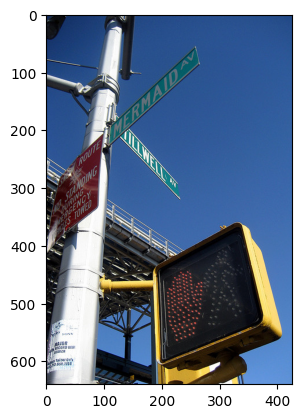

The image features a street pole with several street signs attached to it. The pole is situated in a city environment, with a pedestrian crossing sign and a traffic light visible on the pole. There are multiple street signs on the pole, including a sign for Mermaid Avenue and a sign for Broadway. The pole is positioned in the middle of the scene, with the signs and traffic light visible from all sides. The traffic light is located at the top of the pole, indicating the direction of traffic flow.


In [7]:
output_text = model_loader.decode(outputs)[0]
plt.imshow(image)
plt.show()
print(output_text)

In [8]:
with torch.inference_mode():
    output_dict, uncond_output_dict = model_loader.llm_model.generate(
        do_sample=sample,
        temperature=temperature,
        top_p=top_p,
        num_beams=num_beams,
        max_new_tokens=max_new_tokens,
        use_jsd=use_jsd,
        alpha = alpha,
        beta = beta,
        threshold_top_p=threshold_top_p, 
        threshold_top_k=threshold_top_k,
        early_exit_layers=early_exit_layers,
        return_dict=True,
        return_dict_in_generate=True,
        output_hidden_states=True,
        output_scores=True,
        **kwargs,
    )


In [9]:
output_ids = output_dict.sequences
outputs = model_loader.decode(output_ids)[0]

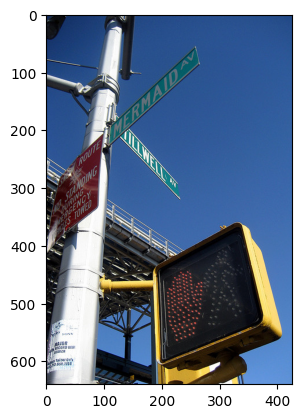

Ours:
 The scene features a street pole under a blue sky, displaying several street signs. There are two street signs, a green Mermaid Avenue and a red Mermaid and Broadway, both located near the top of the pole. Additionally, there are multiple traffic lights throughout the area, including two located close to each other near the center of the pole. A pedestrian crossing sign is also visible, providing guidance for pedestrians to cross the street safely.


In [10]:
plt.imshow(image)
plt.show()
# print("Original:\n", ori_outputs)
# print("\n")
# print("DeCo:\n", deco_outputs)
# print("\n")
print("Ours:\n", outputs)

In [11]:
tokenizer = model_loader.tokenizer
output_ids = output_dict.sequences
if kwargs.get("input_ids", None) is not None:
    input_token_len = kwargs["input_ids"].shape[1]
else:
    input_token_len = 0
start_idx = 10
outputs_tokens = output_ids[0, input_token_len:]
words = tokenizer.decode(outputs_tokens[start_idx:start_idx+50]).encode("unicode_escape").decode()
print(words)

sky, displaying several street signs. There are two street signs, a green Mermaid Avenue and a red Mermaid and Broadway, both located near the top of the pole. Additionally, there are multiple traffic lights throughout the area, including two


In [12]:
# token_idx = -68
# token_idx = -63
# token_idx = -42
token_idx = 9
threshold_top_k = 10
layer_logits = []
uncond_layer_logits = []

hidden_states = output_dict.hidden_states[token_idx]
uncond_hidden_states = uncond_output_dict.hidden_states[token_idx]

if model == "qwen-vl":
    layer_norm = model_loader.llm_model.transformer.ln_f
else:
    layer_norm = model_loader.llm_model.model.norm

for layer_id in range(0, 33):
    if layer_id != 32:
        layer_output = layer_norm(hidden_states[layer_id])
        uncond_layer_output = layer_norm(uncond_hidden_states[layer_id])
    else:
        layer_output = hidden_states[layer_id].clone()
        uncond_layer_output = uncond_hidden_states[layer_id].clone()
    logits = model_loader.llm_model.lm_head(layer_output)[:,-1,:]
    uncond_logits = model_loader.llm_model.lm_head(uncond_layer_output)[:,-1,:]
    layer_logits.append(logits)
    uncond_layer_logits.append(uncond_logits)

stacked_layer_logits = torch.stack(layer_logits, dim=0) # shape: (num_layers, batch_size, vocab_size)
stacked_uncond_layer_logits = torch.stack(uncond_layer_logits, dim=0)

layer_softmax = F.softmax(stacked_layer_logits, dim=-1) # shape: (num_layers, batch_size, vocab_size)
uncond_layer_softmax = F.softmax(stacked_uncond_layer_logits, dim=-1)

layer_log_softmax = F.log_softmax(stacked_layer_logits, dim=-1)
uncond_layer_log_softmax =F.log_softmax(stacked_uncond_layer_logits, dim=-1)

final_layer_softmax = layer_softmax[-1, :, :]
final_layer_log_softmax = layer_log_softmax[-1, :, :]

In [13]:
probs = layer_softmax.squeeze()
uncond_probs = uncond_layer_softmax.squeeze()
# probs = layer_log_softmax.squeeze()
# uncond_probs = uncond_layer_log_softmax.squeeze()

candidate_tokens_probs, candidate_tokens_ids = torch.topk(probs[-1], dim=-1, k=threshold_top_k)

candidate_tokens_cumulative_probs = candidate_tokens_probs.cumsum(dim=-1).float()
candidate_tokens_indices = torch.searchsorted(candidate_tokens_cumulative_probs, threshold_top_p, right=False)
candidate_tokens_cutoff_idx = torch.min(candidate_tokens_indices + 1, torch.tensor(threshold_top_k))   

candidate_tokens_ids = candidate_tokens_ids[:candidate_tokens_cutoff_idx]

candidate_tokens_early_exit_probs = probs[:,candidate_tokens_ids]
uncond_candidate_tokens_early_exit_probs = uncond_probs[:,candidate_tokens_ids]

words = [tokenizer.decode(t.cpu()).encode("unicode_escape").decode() for t in candidate_tokens_ids]

final_softmax_score = F.softmax(output_dict.scores[token_idx][0], dim=-1)
final_tokens_probs, final_tokens_ids = torch.topk(final_softmax_score, dim=-1, k=threshold_top_k)

final_words = [tokenizer.decode(t.cpu()).encode("unicode_escape").decode() for t in final_tokens_ids]

print("top_p_candidate_tokens\n", words)
print(candidate_tokens_probs[:candidate_tokens_cutoff_idx])

print("final_tokens\n", final_words)
print(final_tokens_probs)

top_p_candidate_tokens
 ['sky']
tensor([0.9761], device='cuda:0', dtype=torch.float16)
final_tokens
 ['sky', '<s>', '<0x00>', '<0x03>', '<0x04>', '<unk>', '</s>', '<0x02>', '<0x05>', '<0x01>']
tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')


In [14]:
# cross layer JSD
M = 0.5 * (layer_softmax[...,candidate_tokens_ids] + uncond_layer_softmax[...,candidate_tokens_ids])

kl1 = F.kl_div(layer_log_softmax[...,candidate_tokens_ids], M, reduction='none').mean(-1) # shape: (num_layers, batch_size)
kl2 = F.kl_div(uncond_layer_log_softmax[...,candidate_tokens_ids], M, reduction='none').mean(-1)
js_divs = 0.5 * (kl1 + kl2)
cross_layer_js_divs = js_divs.mean(-1) # shape: (num_layers,)

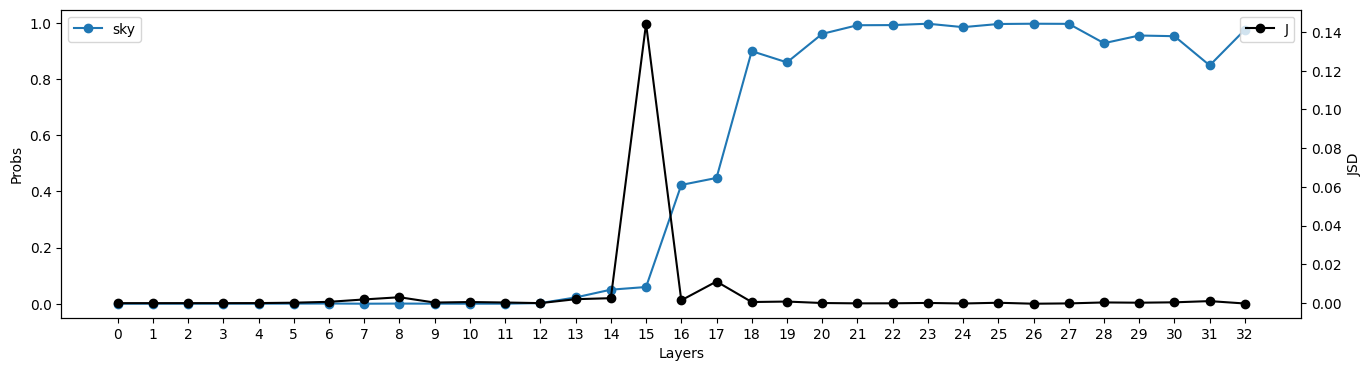

Max JS divergence idx:  15


In [15]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(candidate_tokens_early_exit_probs.detach().cpu().numpy(), marker = 'o')
ax.set_xlabel("Layers")
ax.set_ylabel("Probs")
ax.set_xticks(range(33))
# ax.set_ylim(0, 1)
ax.legend(words, loc='upper left')

# jsd = cross_layer_js_divs.max() - cross_layer_js_divs
jsd = cross_layer_js_divs

ax2 = ax.twinx()
ax2.plot(jsd.detach().cpu().numpy(), marker = 'o', color = 'black')
ax2.set_ylabel("JSD")
ax2.legend("J")

plt.show()
print("Max JS divergence idx: ", jsd.argmax().item())

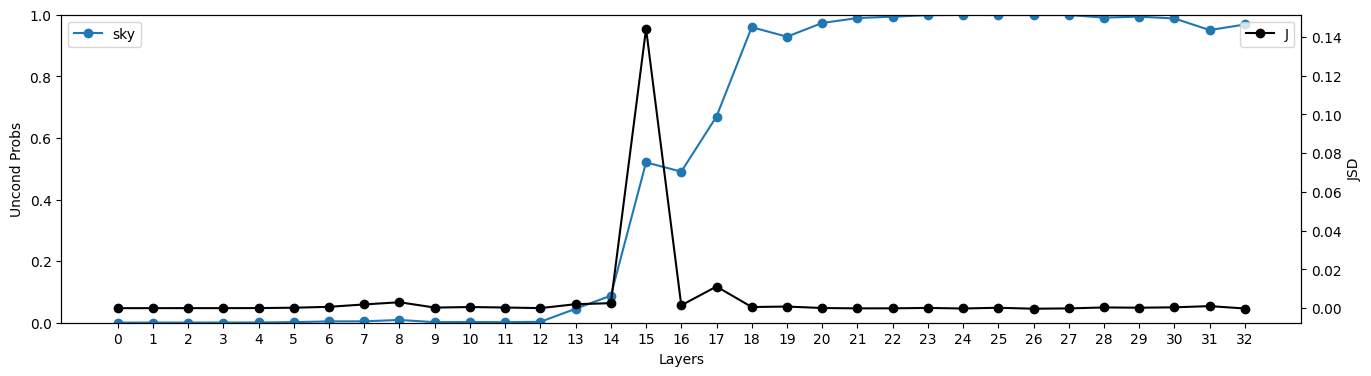

In [16]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(uncond_candidate_tokens_early_exit_probs.detach().cpu().numpy(), marker = 'o')
ax.set_xlabel("Layers")
ax.set_ylabel("Uncond Probs")
ax.set_xticks(range(33))
ax.set_ylim(0, 1)
ax.legend(words, loc='upper left')

# jsd = cross_layer_js_divs.max() - cross_layer_js_divs
jsd = cross_layer_js_divs

ax2 = ax.twinx()
ax2.plot(jsd.detach().cpu().numpy(), marker = 'o', color = 'black')
ax2.set_ylabel("JSD")
ax2.legend("J")

plt.show()